<a href="https://colab.research.google.com/github/Eliezer-Carvalho/IP/blob/master/Game_Plan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Código Normal

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen3-8B"

# load the tokenizer and the model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype = "auto",
    device_map = "auto"
)

# prepare the model input
prompt = "Give me a short introduction to large language model."
messages = [
    {"role": "user", "content": prompt}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize = False,
    add_generation_prompt =True,
    enable_thinking = False # Switches between thinking and non-thinking modes. Default is True.
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

# conduct text completion
generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=32768
)
output_ids = generated_ids[0][len(model_inputs.input_ids[0]):].tolist()

# parsing thinking content
try:
    # rindex finding 151668 (</think>)
    index = len(output_ids) - output_ids[::-1].index(151668)
except ValueError:
    index = 0

thinking_content = tokenizer.decode(output_ids[:index], skip_special_tokens=True).strip("\n")
content = tokenizer.decode(output_ids[index:], skip_special_tokens=True).strip("\n")

print("thinking content:", thinking_content)
print("content:", content)


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

KeyboardInterrupt: 

Código Simples

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "gpt2" #Modelo
tokenizer = AutoTokenizer.from_pretrained(model_name) #Carrega o Tokenizer do modelo
model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype="auto", device_map="cpu") #Carrega o modelo Localmente

# Texto inicial
prompt = "Hoje o céu está"

# Tokeniza
inputs = tokenizer(prompt, return_tensors="pt")

# Gera texto
outputs = model.generate(**inputs, max_length = 20)
print(tokenizer.decode(outputs[0]))

Sacando o modelo

In [ ]:
from transformers import AutoModel, AutoTokenizer

model_path = "./caminho/para/a/pasta"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModel.from_pretrained(model_path, device_map="auto")  # device_map="auto" se tiver GPU

Passo 1 – Escolher o modelo

Decidir qual modelo vai rodar localmente, considerando:

Tamanho do modelo (número de parâmetros)
Pequeno (2–7B) → roda em CPU ou GPU modesta.
Médio (7–13B) → precisa de GPU decente.
Grande (13–70B) → exige GPU potente e/ou CPU+GPU híbrido.
Compatibilidade
Deve ser compatível com llama.cpp.


Modelos quantizados usam menos memória e VRAM, importantes para offline.
Quantizações típicas: 4-bit, 5-bit, 8-bit.

💡 Dica: Para começar, um modelo 7B quantizado em 4–5 bits é excelente para testar offline e já usar RAG depois.

Passo 2 – Hospedar no llama.cpp

Depois de escolher o modelo:

Converter o modelo para formato ggml/llama.cpp (se necessário)
A maioria dos modelos open-source precisa ser convertida para um formato que o llama.cpp entenda.
Rodar o modelo offline
Pode ser apenas CPU, GPU, ou CPU+GPU híbrido.
O llama.cpp já suporta quantização, o que ajuda a economizar memória.
Expor uma API local (opcional, mas recomendado)
Usar text-generation-webui ou criar um pequeno servidor Python para interagir com o modelo.
Isso facilita integrar o modelo a qualquer aplicação futura de RAG.
Passo 3 – Aplicar RAG ou outras técnicas

Depois que o modelo estiver rodando offline, você pode integrar técnicas de RAG (Recuperação + Geração):

Como funciona RAG:
Indexa documentos (localmente ou via embeddings).
Quando o usuário faz uma pergunta, o sistema recupera os trechos relevantes.
O LLM gera a resposta usando esses trechos como contexto.
Benefício do offline:
Seus dados nunca saem da máquina.
Você controla totalmente a segurança e privacidade.
Ferramentas comuns para RAG offline:
LangChain ou LlamaIndex (podem se conectar ao seu LLM local).
FAISS ou Chroma para indexação de embeddings.

1 - Escolher o modelo (Possibilidade de criar um - Distillation | Modelo Instruído vs Não Instruído)

2 - Hardware (VRAM, Bandwidth, FLOPs, MFU)

3 - Model Compression (Quantization, Pruning, GGUF)

4 - Host (llama.cpp)

Métricas de Qualidade do Modelo

*   Perplexity
*   BenchMarks
*   Avaliação Humana

*   VRAM/CPU Utilizada
*   Latência -> Número de Tokens Por Segundo


Passo 1: Prepara os modelos
Modelo “puro”: sem quantization/pruning, rodando full precision
Modelo otimizado: quantization + pruning +, se quiser, CPU/GPU híbrido
Passo 2: Rodar benchmarks de inferência
Escolhe um conjunto de prompts (QA, summarization, completude de texto)
Mede:
Tempo de resposta médio
Tokens processados por segundo
Uso de VRAM e RAM
Passo 3: Rodar benchmarks de qualidade
Mede perplexity em dataset de teste
Compara respostas em tarefas específicas
Opcional: avaliação humana em 10–20 prompts
Passo 4: Analisa trade-offs
Quanto ganhou em performance (VRAM, velocidade)
Quanto perdeu em qualidade (PPL, acurácia QA, avaliação humana)
Decide se o trade-off é aceitável para seu caso de uso offline/RAG

Framework Profissional para Hospedagem Offline de LLMs em Empresas
1️⃣ Estratégia de Modelos
Escolha do modelo base:
Open-source (LLaMA, Falcon, MPT, GPT4All, Mistral)
Definir tamanho inicial (7B, 13B, 16B) com base em hardware disponível e uso esperado
Criação de SLM próprio (opcional):
Distillation para criar modelos menores mantendo a performance
Foco em domínio específico da empresa
Versões para benchmarking:
Full precision (baseline)
Quantized (4-bit, 5-bit)
Quantized + pruning
CPU/GPU híbrido, se necessário
2️⃣ Planejamento de Hardware Profissional
Parâmetros essenciais para decidir hardware:
VRAM (tamanho do modelo quantizado)
Memory Footprint (MFU)
FLOPs (carga de computação)
Bandwidth (CPU↔GPU, armazenamento)
Configuração prática:
GPU consumer: RTX 3060–4070 → modelos 7B quantizados
GPU avançada: RTX 4090 / A6000 → 13B–16B
CPU+GPU híbrido para modelos maiores ou múltiplos usuários simultâneos
Cálculo de custo:
Hardware inicial
Consumo energético estimado
ROI para empresas (quanto economizam em nuvem vs offline)
3️⃣ Model Compression e Otimização
Quantization:
4-bit ou 5-bit para maximizar economia de VRAM sem grande perda de qualidade
Pruning:
Remoção de pesos/neuronios redundantes
Aplicar pruning moderado (20–30%) para manter performance
CPU/GPU híbrido:
Permite hospedar modelos > VRAM disponível
Ideal para empresas que não querem investir em GPUs topo de linha
Pipeline automatizado:
Scripts que geram versões otimizadas automaticamente
Comparação de trade-offs performance vs qualidade
4️⃣ Hospedagem e Interface
Host offline usando llama.cpp
Suporte a quantization, CPU/GPU híbrido, benchmarks
API local ou WebUI
Facilita integração com apps da empresa
Permite RAG e queries escaláveis
Integração futura com RAG
FAISS / Chroma para indexação de documentos
Pipeline de recuperação + geração totalmente local
5️⃣ Métricas Profissionais de Benchmarking
Qualidade
Perplexity
QA Accuracy (datasets de domínio)
Benchmarks públicos (MMLU, TruthfulQA, BigBench)
Avaliação humana (10–20 prompts críticos)
Performance
Latência (tempo/resposta, tokens/s)
VRAM e RAM utilizadas
Throughput de inferência\
Consumo energético (opcional para custo real)
6️⃣ Passo a Passo Profissional de Benchmarking
Preparar modelos:
Full precision
Otimizado (quant/prune/híbrido)
Rodar benchmarks de inferência:
Prompts reais da empresa (QA, summarization)
Medir VRAM, RAM, throughput, latência
Rodar benchmarks de qualidade:
Dataset de teste
Perplexity e QA accuracy
Avaliação humana crítica
Analise trade-offs:
Comparar performance vs qualidade
Decidir versão ideal para produção offline
Preparar pipeline RAG:
Indexar documentos relevantes
Integrar ao modelo otimizado para uso real

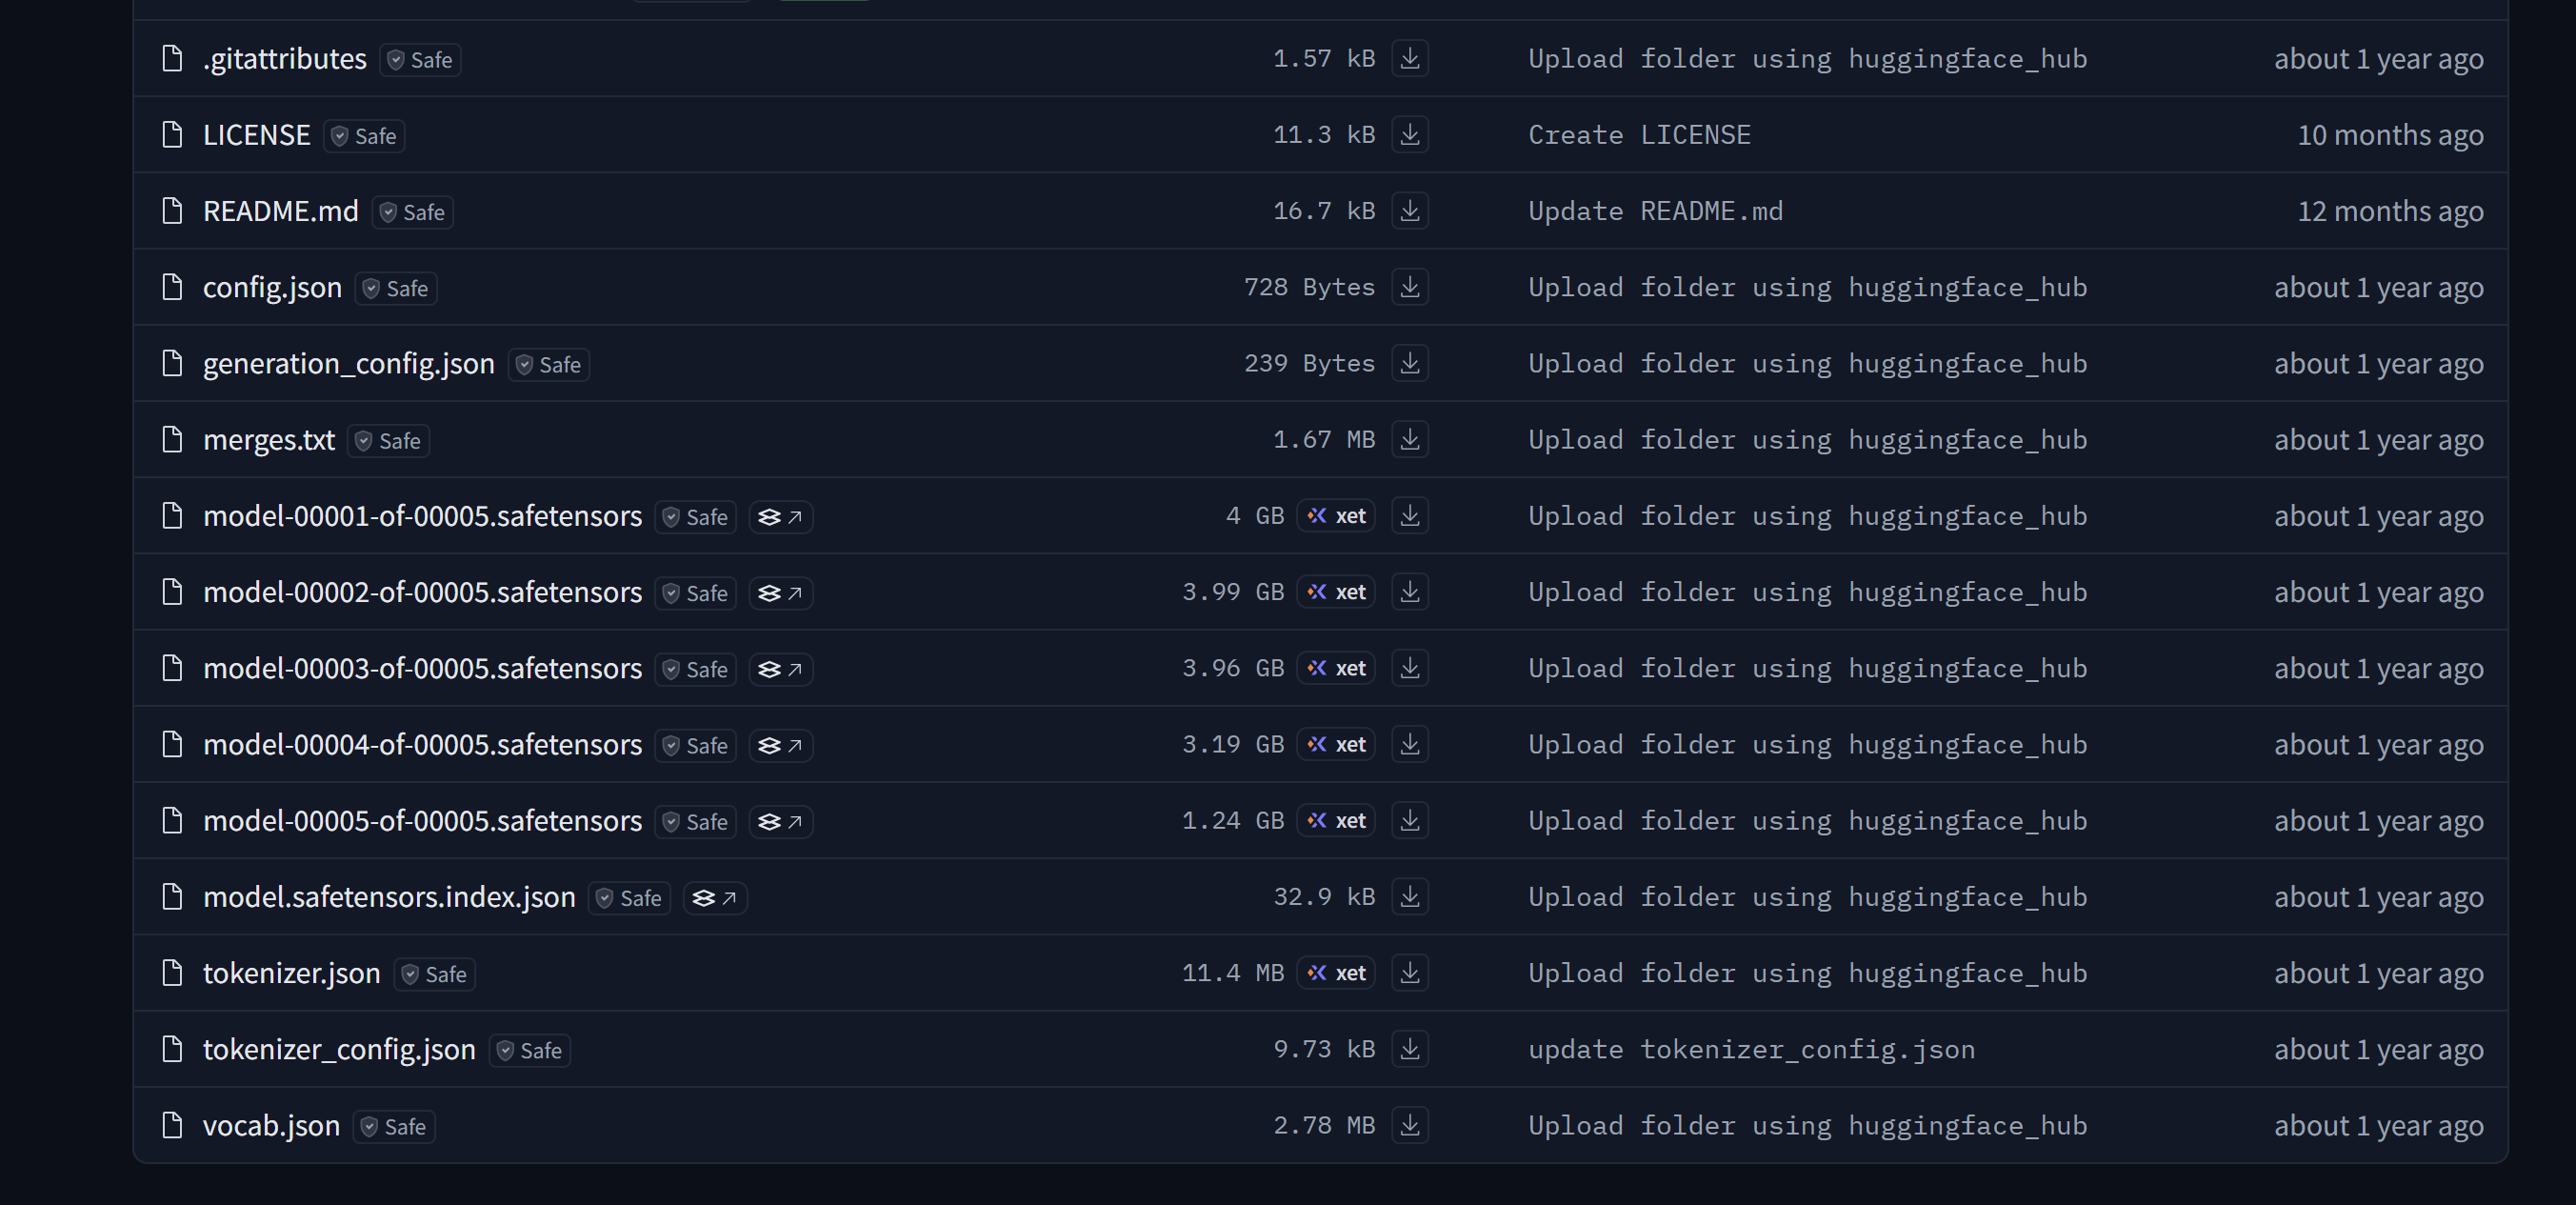


Importante -> Tudo menos README, LICENSE, gitatributes